# 머신러닝 핵심 알고리즘

## 지도 학습

### K-최근접 이웃

##### 라이브러리 호출 및 데이터 준비

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics

names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']

from google.colab import files # 데이터 불러오기
file_uploaded=files.upload()   # 데이터 불러오기
dataset = pd.read_csv('iris.data', names=names)

Saving iris.data to iris.data


##### 훈련과 테스트 데이터셋 분리

In [3]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 4].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

from sklearn.preprocessing import StandardScaler
s = StandardScaler() # 특성 스케일링, 평균이 0, 표준편차가 1이 되도록 변환
X_train = s.fit_transform(X_train)
X_test = s.fit_transform(X_test)

##### 모델 생성 및 훈련

In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50)

##### 모델 정확도

In [11]:
from sklearn.metrics import accuracy_score
y_pred = knn.predict(X_test)
print("정확도: {}".format(accuracy_score(y_test, y_pred)))

정확도: 0.9


##### 최적의 K 찾기

In [12]:
k = 10
acc_array = np.zeros(k)
for k in np.arange(1, k+1, 1):
    classifier = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    acc = metrics.accuracy_score(y_test, y_pred)
    acc_array[k-1] = acc

max_acc = np.amax(acc_array)
acc_list = list(acc_array)
k = acc_list.index(max_acc)
print("정확도", max_acc, "으로 최적의 k는", k + 1, "입니다")

정확도 0.8666666666666667 으로 최적의 k는 2 입니다


### 서포트 벡터 머신

##### 라이브러리 호출

In [13]:
from sklearn import svm, metrics, datasets, model_selection
import tensorflow as tf
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

##### iris 데이터를 준비하고 훈련과 테스트 데이터셋응로 분리

In [14]:
iris = datasets.load_iris()
X_train, X_test, y_train, y_test = model_selection.train_test_split(iris.data,
                                                                    iris.target,
                                                                    test_size=0.6,
                                                                    random_state=42)

##### SVM 모델에 대한 정확도

In [15]:
svm = svm.SVC(kernel='linear', C=1.0, gamma=0.5)
svm.fit(X_train, y_train) # 훈련 데이터를 사용해 SVM 분류기를 훈련
predictions = svm.predict(X_test) # 훈련된 모델을 사용하여 테스트 데이터에서 예측
score = metrics.accuracy_score(y_test, predictions)
print("정확도: {0:f}".format(score)) # 테스트 데이터 정확도 측정

정확도: 0.988889


### 결정 트리

##### 라이브러리 호출 및 데이터 준비

In [16]:
import pandas as pd
from google.colab import files # 데이터 불러오기
file_uploaded=files.upload()   # 데이터 불러오기
df = pd.read_csv('train.csv', index_col='PassengerId')
print(df.head())

Saving train.csv to train.csv
             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   

             SibSp  Parch            Ticket     Fare Cabin Embarked  
PassengerId                                                          
1                1      0         A/5

##### 타이타닉 전체 데이터 중 분석에 필요한 컬럼만 추출하여 전처리

In [18]:
df = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']]
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1}) # 성별을 나타내는 sex를 0 또는 1의 정수로 변환
df = df.dropna() # 값이 없는 데이터 삭제
X = df.drop('Survived', axis=1)
y = df['Survived'] # 'Survived' 값을 예측 레이블로 사용

##### 훈련과 테스트 데이터셋으로 분리

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

##### 결정 트리 모델 생성

In [20]:
from sklearn import tree
model = tree.DecisionTreeClassifier()

##### 모델 훈련

In [23]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

##### 테스트 데이터셋을 이용하여 모델에 대한 예측 진행

In [24]:
y_predict = model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predict)

0.8268156424581006

##### 혼동 행렬을 이용한 성능 측정

In [25]:
from sklearn.metrics import confusion_matrix
pd.DataFrame(
    confusion_matrix(y_test, y_predict),
    columns=['Predicted Not Survival', 'Predicted Survival'],
    index=['True Not Survival', 'True Survival']
)

,Predicted Not Survival,Predicted Survival
True Not Survival,99,13
True Survival,18,49


### 로지스틱 회귀와 선형 회귀

#### 로지스틱 회귀

##### 라이브러리 호출 및 데이터 준비

In [27]:
%matplotlib inline
from sklearn.datasets import load_digits
digits = load_digits() # 숫자 데이터셋

print("Image Data Shape", digits.data.shape)
print("Label Data Shape", digits.target.shape)

Image Data Shape (1797, 64)
Label Data Shape (1797,)


##### digits 데이터셋 시각화

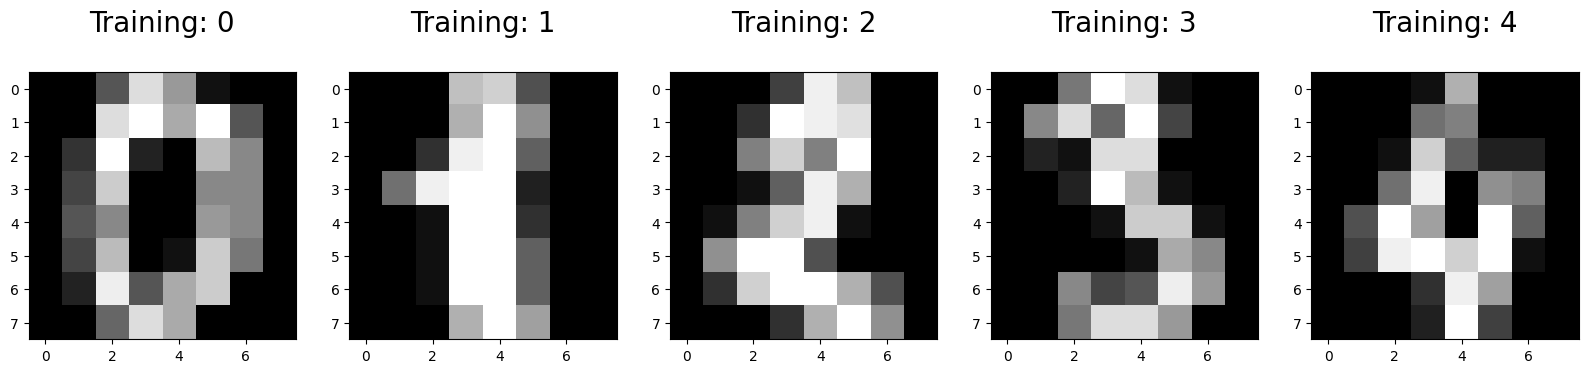

In [28]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 4))
for index, (image, label) in enumerate(zip(digits.data[0:5], digits.target[0:5])):
    plt.subplot(1, 5, index + 1)
    plt.imshow(np.reshape(image, (8, 8)), cmap=plt.cm.gray)
    plt.title('Training: %i\n' % label, fontsize=20)

##### 훈련과 테스트 데이터셋 분리 및 로지스틱 회귀 모델 생성

In [29]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(digits.data, digits.target,
                                                    test_size=0.25, random_state=0)

from sklearn.linear_model import LogisticRegression
logisticRegr = LogisticRegression()
logisticRegr.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

##### 일부 데이터를 사용한 모델 예측

In [30]:
logisticRegr.predict(x_test[0].reshape(1, -1)) # 새로운 이미지에 대한 예측 결과를 넘파이 배열로 출력
logisticRegr.predict(x_test[0:10])

array([2, 8, 2, 6, 6, 7, 1, 9, 8, 5])

##### 전체 데이터를 사용한 모델 예측

In [31]:
predictions = logisticRegr.predict(x_test)
score = logisticRegr.score(x_test, y_test)
print(score)

0.9511111111111111


##### 혼동 행렬 시각화

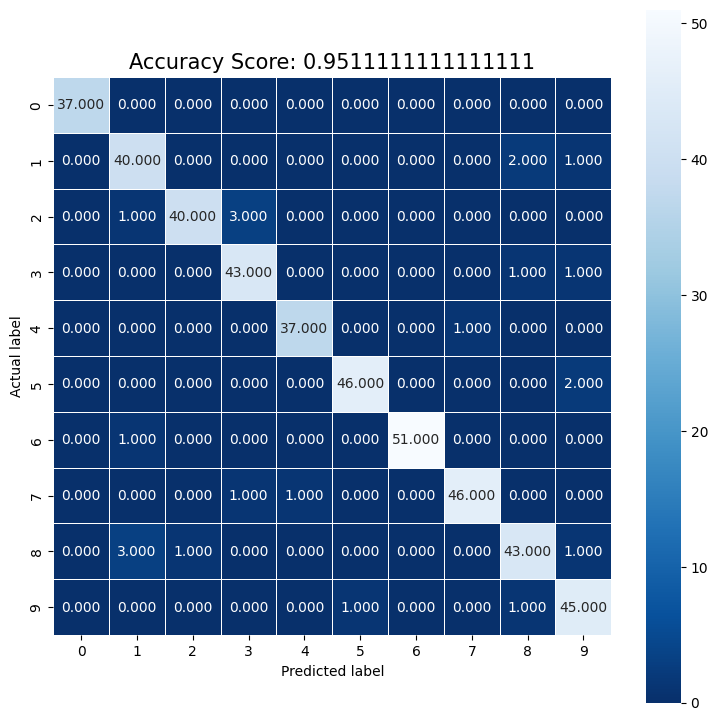

In [32]:
import numpy as np
import seaborn as sns
from sklearn import metrics

cm = metrics.confusion_matrix(y_test, predictions)
plt.figure(figsize=(9, 9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square=True, cmap='Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(score)
plt.title(all_sample_title, size=15);
plt.show()

#### 선형 회귀

##### 라이브러리 호출

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seabornInstance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline

##### 데이터셋 불러오기

In [34]:
from google.colab import files # 데이터 불러오기
file_uploaded=files.upload()   # 데이터 불러오기
dataset = pd.read_csv('weather.csv')

Saving weather.csv to weather.csv


##### 데이터 간 관계를 시각화로 표현

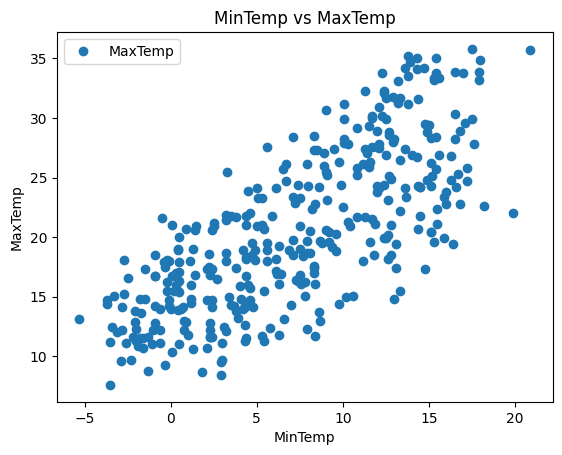

In [35]:
dataset.plot(x='MinTemp', y='MaxTemp', style='o')
plt.title('MinTemp vs MaxTemp')
plt.xlabel('MinTemp')
plt.ylabel('MaxTemp')
plt.show()

##### 데이터를 독립 변수와 종속 변수로 분리하고 선형 회귀 모델 생성

In [36]:
X = dataset['MinTemp'].values.reshape(-1, 1)
y = dataset['MaxTemp'].values.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

##### 회귀 모델에 대한 예측

In [37]:
y_pred = regressor.predict(X_test)
df = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': y_pred.flatten()})
df

,Actual,Predicted
0,18.1,14.231299
1,24.3,26.923689
2,13.1,10.000502
3,27.4,25.679337
4,20.7,18.876880
...,...,...
69,27.4,22.278109
70,14.5,17.964355
71,33.9,28.085085
72,27.1,23.854288


##### 테스트 데이터셋을 사용한 회귀선 표현

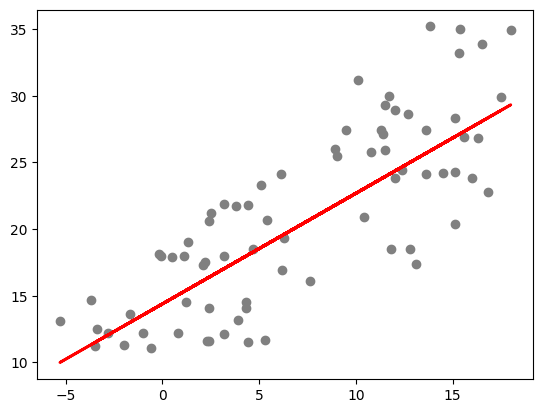

In [38]:
plt.scatter(X_test, y_test, color='gray')
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.show()

##### 선형 회귀 모델 평가

In [43]:
print('평균제곱법:', metrics.mean_squared_error(y_test, y_pred))
print('루트 평균제곱법:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

평균제곱법: 16.90386141333179
루트 평균제곱법: 4.111430579899385


## 비지도 학습

### K-평균 군집화

##### 라이브러리 호출

In [44]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

##### 데이터 가져오기

In [45]:
from google.colab import files # 데이터 불러오기
file_uploaded=files.upload()   # 데이터 불러오기
data = pd.read_csv('sales data.csv')
data.head()

Saving sales data.csv to sales data.csv


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


##### 연속형 데이터와 명목형 데이터로 분류

In [46]:
categorical_features = ['Channel', 'Region']
numerical_features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

for col in categorical_features:
    dummies = pd.get_dummies(data[col], prefix=col)
    data = pd.concat([data, dummies], axis=1)
    data.drop(col, axis=1, inplace=True)

data.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_1,Channel_2,Region_1,Region_2,Region_3
0,12669,9656,7561,214,2674,1338,False,True,False,False,True
1,7057,9810,9568,1762,3293,1776,False,True,False,False,True
2,6353,8808,7684,2405,3516,7844,False,True,False,False,True
3,13265,1196,4221,6404,507,1788,True,False,False,False,True
4,22615,5410,7198,3915,1777,5185,False,True,False,False,True


##### 데이터 전처리 - 스케일링

In [47]:
mms = MinMaxScaler()
mms.fit(data)
data_transformed = mms.transform(data)

##### 적당한 K값 추출

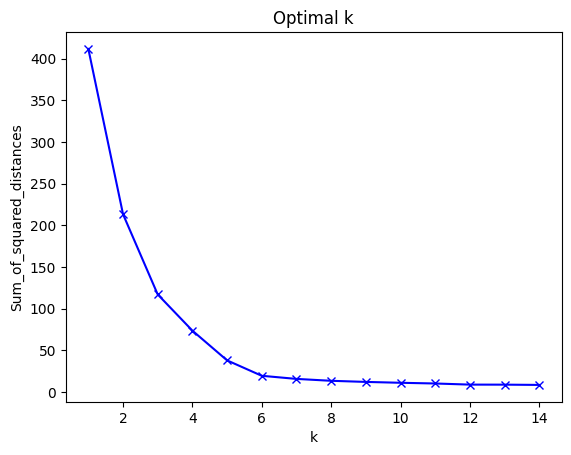

In [52]:
Sum_of_squared_distances = []
K = range(1, 15)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(data_transformed)
    Sum_of_squared_distances.append(km.inertia_)

plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Optimal k')
plt.show()

### 주성분 분석(PCA)

##### 라이브러리 호출

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

##### 데이터 불러오기

In [54]:
from google.colab import files # 데이터 불러오기
file_uploaded=files.upload()   # 데이터 불러오기
X = pd.read_csv('credit card.csv')
X = X.drop('CUST_ID', axis = 1)
X.fillna(method ='ffill', inplace = True)
print(X.head())

Saving credit card.csv to credit card.csv
       BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0    40.900749           0.818182      95.40              0.00   
1  3202.467416           0.909091       0.00              0.00   
2  2495.148862           1.000000     773.17            773.17   
3  1666.670542           0.636364    1499.00           1499.00   
4   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000             

/tmp/ipykernel_470/982787110.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X.fillna(method ='ffill', inplace = True)


##### 데이터 전처리 및 데이터 차원 축소

In [55]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_normalized = normalize(X_scaled)
X_normalized = pd.DataFrame(X_normalized)

pca = PCA(n_components = 2)
X_principal = pca.fit_transform(X_normalized)
X_principal = pd.DataFrame(X_principal)
X_principal.columns = ['P1', 'P2']
print(X_principal.head())

         P1        P2
0 -0.489949 -0.679976
1 -0.519099  0.544827
2  0.330633  0.268879
3 -0.481656 -0.097611
4 -0.563512 -0.482506


##### DBSCAN 모델 생성 및 결과 시각화

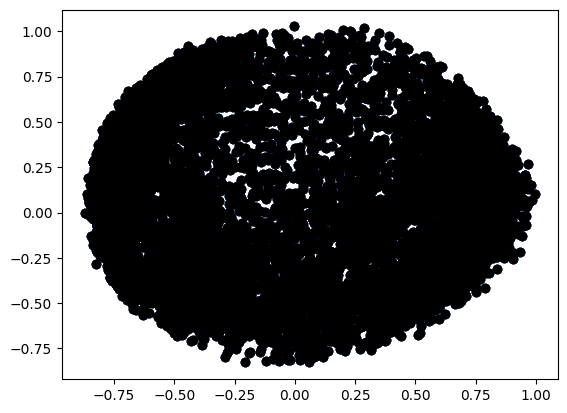

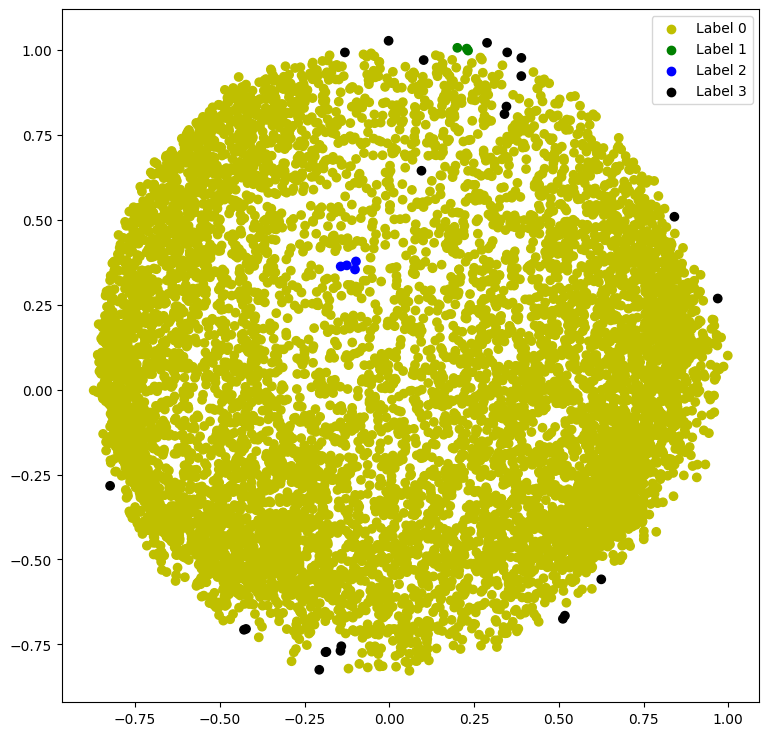

In [57]:
db_default = DBSCAN(eps = 0.0375, min_samples = 3).fit(X_principal)
labels = db_default.labels_

colours = {}
colours[0] = 'y'
colours[1] = 'g'
colours[2] = 'b'
colours[-1] = 'k'

cvec = [colours[label] for label in labels] # 각 데이터 포인터에 대한 색상 벡터 생성

r = plt.scatter(X_principal['P1'], X_principal['P2'], color = 'y')
g = plt.scatter(X_principal['P1'], X_principal['P2'], color = 'g')
b = plt.scatter(X_principal['P1'], X_principal['P2'], color = 'b')
k = plt.scatter(X_principal['P1'], X_principal['P2'], color = 'k')

plt.figure(figsize = (9, 9))
plt.scatter(X_principal['P1'], X_principal['P2'], c = cvec)

plt.legend((r, g, b, k), ('Label 0', 'Label 1', 'Label 2', 'Label 3'))
plt.show()

##### 모델 튜닝

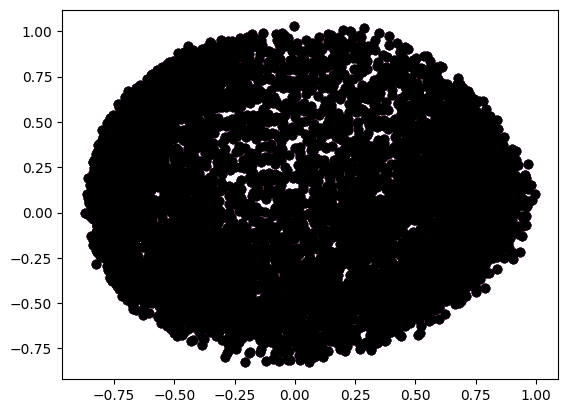

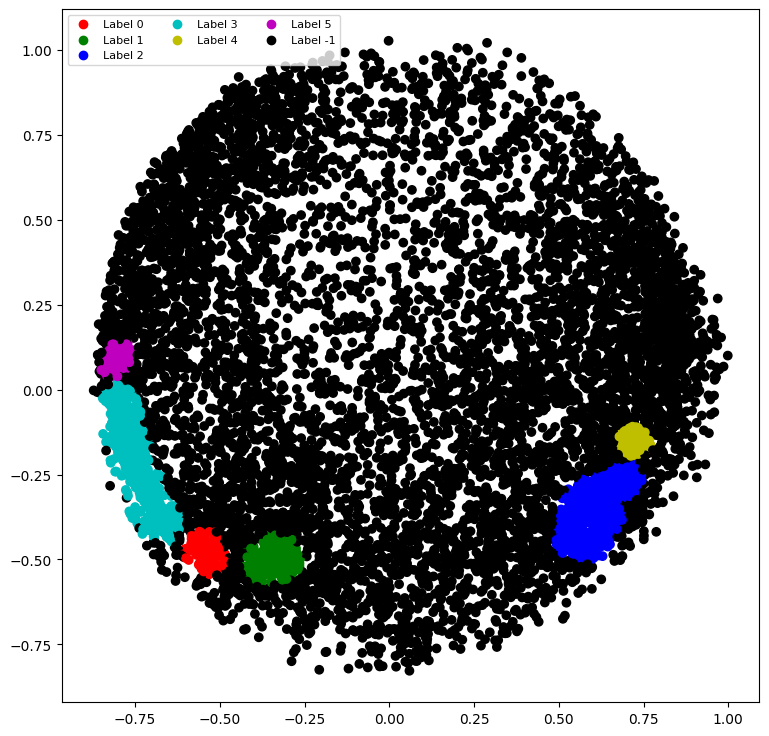

In [58]:
db = DBSCAN(eps = 0.0375, min_samples = 50).fit(X_principal)
labels1 = db.labels_

colours1 = {}
colours1[0] = 'r'
colours1[1] = 'g'
colours1[2] = 'b'
colours1[3] = 'c'
colours1[4] = 'y'
colours1[5] = 'm'
colours1[-1] = 'k'

cvec = [colours1[label] for label in labels1]
colors1 = ['r', 'g', 'b', 'c', 'y', 'm', 'k' ]

r = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[0])
g = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[1])
b = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[2])
c = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[3])
y = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[4])
m = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[5])
k = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[6])

plt.figure(figsize =(9, 9))
plt.scatter(X_principal['P1'], X_principal['P2'], c = cvec)
plt.legend((r, g, b, c, y, m, k),
           ('Label 0', 'Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label -1'),
           scatterpoints = 1,
           loc ='upper left',
           ncol = 3,
           fontsize = 8)
plt.show()

##### 잘못된 하이퍼파라미터 적용시

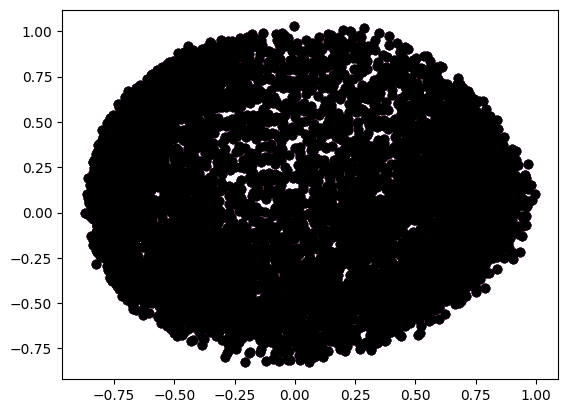

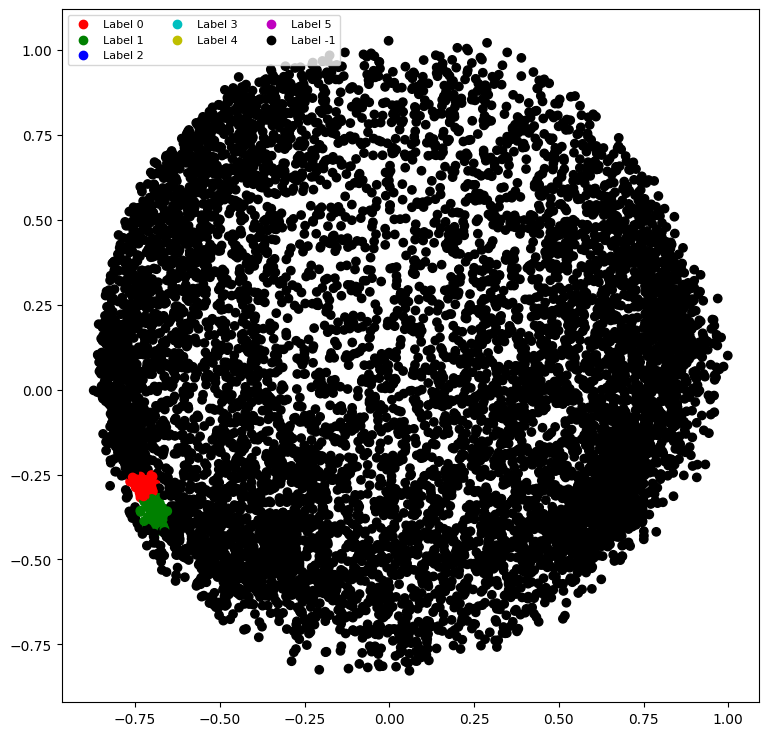

In [59]:
db = DBSCAN(eps = 0.0375, min_samples = 100).fit(X_principal)
labels1 = db.labels_

colours1 = {}
colours1[0] = 'r'
colours1[1] = 'g'
colours1[2] = 'b'
colours1[3] = 'c'
colours1[4] = 'y'
colours1[5] = 'm'
colours1[-1] = 'k'

cvec = [colours1[label] for label in labels1]
colors1 = ['r', 'g', 'b', 'c', 'y', 'm', 'k' ]

r = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[0])
g = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[1])
b = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[2])
c = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[3])
y = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[4])
m = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[5])
k = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[6])

plt.figure(figsize =(9, 9))
plt.scatter(X_principal['P1'], X_principal['P2'], c = cvec)
plt.legend((r, g, b, c, y, m, k),
           ('Label 0', 'Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label -1'),
           scatterpoints = 1,
           loc ='upper left',
           ncol = 3,
           fontsize = 8)
plt.show()